Tarefa: Geração de imagens de roupas - base Fashion MNIST
Olá!

Nesta tarefa você vai usar a base de dados Fashion MNIST, que possui 10 classes com tipos de roupas. O PyTorch já disponibiliza essa base de dados, bastando que você faça o carregamento igual já fizemos para a base de dados MNIST. Como as imagens também estão em escala de cinza e possuem as mesmas dimensões, não são necessárias alterações no código para fazer esse teste.

Abaixo você pode visualizar algumas das imagens que foram criadas. Como essa base de dados é um pouco mais complexa, sugerimos que você faça o treinamento por mais épocas, adicione mais camadas nas redes neurais e implemente uma rede neural convolucional para o discriminador


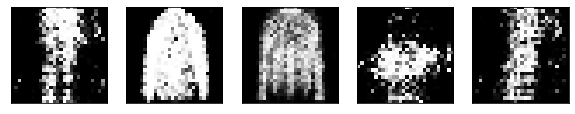

Jones

# Tarefa: Geração de novas imagens com GANs - base Fashion MNIST

## Etapa 1: Importação das bibliotecas

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets
import torchvision.transforms as transforms
torch.__version__

'2.9.1+cpu'

In [2]:

# ambiente anaconda
import sys
print(sys.executable) # orange3 ou youtube
import sys
print(sys.version)

/home/fabiene/anaconda3/envs/orange3/bin/python
3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]


In [3]:
torch.manual_seed(123) # semente, sempre gerar o mesmo valor

## Etapa 2: Base de dados

In [4]:
# Converte a imagem (geralmente em formato PIL ou NumPy) para um Tensor do PyTorch.
# Além disso, ele escala os pixels que são de 0-255 para o intervalo [0.0, 1.0].
# Isso é fundamental para que os cálculos matemáticos da rede funcionem bem.
transform = transforms.ToTensor()

# Carrega o dataset FashionMNIST (roupas, sapatos, etc.).
# root = '.': Salva os arquivos na pasta atual.
# train = True: Pega as 60.000 imagens de treino (não as de teste).
# download = True: Se os arquivos não estiverem na pasta, ele baixa automaticamente.
# transform = transform: Aplica a conversão para Tensor que definimos acima em cada imagem.
train = datasets.FashionMNIST(root = '.', train = True, download = True,
                       transform = transform)

# Cria o "carregador" que vai entregar os dados para a rede durante o treino.
# batch_size = 256: Em vez de passar uma imagem por vez, ele passa um "lote" de 256 imagens.
# Isso acelera o treino (processamento paralelo) e estabiliza o cálculo do erro (gradiente).
train_loader = torch.utils.data.DataLoader(train, batch_size = 256)

100%|██████████| 26.4M/26.4M [00:23<00:00, 1.14MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 125kB/s]
100%|██████████| 4.42M/4.42M [00:11<00:00, 378kB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.2MB/s]


## Etapa 3: Construção do gerador



arquitetura e o fluxo de dados do Gerador

No contexto de uma GAN, o Gerador é como um "falsificador de arte" que tenta transformar um ruído aleatório em uma imagem que faça sentido (como as roupas do FashionMNIST).

In [5]:
28*28


784

In [6]:
class gerador(nn.Module):
  def __init__(self):
    # Inicializa a classe pai (nn.Module) para herdar os recursos do PyTorch
    super().__init__()
      
    # 100 -> 32 -> 64 -> 128 -> 784
    # Camadas Densas (Lineares):
    # 100 -> 32: Recebe o ruído (espaço latente) e começa a dar forma a ele.
    self.dense0 = nn.Linear(100, 32)
    # 32 -> 64: Aumenta a complexidade dos dados.
    self.dense1 = nn.Linear(32, 64)
    # 64 -> 128: Continua expandindo a informação para criar mais detalhes.
    self.dense2 = nn.Linear(64, 128)
    # 128 -> 784: Camada final que gera os 784 pixels (28x28) da imagem.
    self.dense3 = nn.Linear(128, 784)
    
    # Dropout: Durante o treino, desativa aleatoriamente 30% dos neurônios.
    # Isso evita que o gerador fique "viciado" em um único padrão (overfitting).
    self.dropout = nn.Dropout(0.3)

  def forward(self, X):
    # Passagem dos dados pelas camadas:
    
    # Leaky ReLU: Ativação que permite passar um pouco de sinal negativo (0.2).
    # Isso ajuda a manter o gradiente vivo, evitando que os neurônios "morram".
    X = self.dropout(F.leaky_relu(self.dense0(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense1(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense2(X), 0.2))
    
    # Tanh: Garante que os pixels gerados fiquem entre -1 e 1.
    # É essencial que a imagem real também tenha sido normalizada para essa escala.
    X = torch.tanh(self.dense3(X))
    
    # View: Remodela o vetor achatado de 784 para o formato de imagem 28x28.
    # O X.shape[0] mantém o tamanho do lote (batch size).
    X = X.view(X.shape[0], 28, 28)
    
    return X

## Etapa 4: Construção do discriminador

Discriminador, que atua como o "crítico" ou "policial" da GAN. Enquanto o Gerador tenta criar imagens falsas, o papel desta classe é aprender a distinguir entre as imagens reais (do FashionMNIST) e as falsas (criadas pelo seu Gerador).

In [7]:
class discriminador(nn.Module):
  def __init__(self):
    super().__init__()
    # 784 -> 128 -> 64 -> 32 -> 1
    # Camadas Densas (Lineares) - O "Funil de Decisão":
    # 784 -> 128: Recebe a imagem (28x28 pixels achatados) e começa a extrair padrões.
    self.dense0 = nn.Linear(784, 128)
    # 128 -> 64: Reduz a informação para focar em características mais complexas.
    self.dense1 = nn.Linear(128, 64)
    # 64 -> 32: Refina ainda mais a análise das formas (ex: curvas de uma bota ou manga).
    self.dense2 = nn.Linear(64, 32)
    # 32 -> 1: O veredito final. Um único valor que indica se a imagem é real ou falsa.
    self.dense3 = nn.Linear(32, 1)
    
    # Dropout (0.3): Desativa 30% dos neurônios aleatoriamente durante o treino.
    # É CRUCIAL no discriminador para evitar que ele fique "esperto demais" rápido demais
    # e acabe impedindo o gerador de aprender qualquer coisa.
    self.dropout = nn.Dropout(0.3)

  def forward(self, X):
    # X.view: Garante que a imagem (28, 28) seja "esticada" em um vetor de 784 posições.
    # Isso é necessário porque camadas nn.Linear não entendem matrizes 2D.
    X = X.view(X.shape[0], 28 * 28)
    
    # F.leaky_relu(X, 0.2): Ativação que deixa passar um pouco de sinal negativo.
    # Evita o problema do "neurônio morto" (quando o gradiente para de fluir).
    X = self.dropout(F.leaky_relu(self.dense0(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense1(X), 0.2))
    X = self.dropout(F.leaky_relu(self.dense2(X), 0.2))
    
    # Saída final: Note que aqui não há Sigmoid, o que indica que nós provavelmente
    # usaremos a função de perda "BCEWithLogitsLoss", que é mais estável numericamente.
    X = self.dense3(X)
    
    return X

## Etapa 5: Criação dos objetos

preparação dos motores da sua GAN. Aqui estamos criando os modelos, definindo como eles vão aprender (otimizadores), qual a "regra" do jogo (função de erro) e onde o cálculo será feito (processador ou placa de vídeo).

In [9]:
# Instancia as classes que criamos. 
# G será o responsável por criar imagens, D será o juiz que avalia.
G = gerador()
D = discriminador()

# Define o Otimizador Adam para o Gerador.
# lr = 0.002: É a taxa de aprendizado (learning rate). Define o tamanho do "passo"
# que a rede dá ao ajustar seus pesos. Valores entre 0.0002 e 0.002 são comuns em GANs.
G_optimizer = optim.Adam(G.parameters(), lr = 0.002)

# Define o Otimizador Adam para o Discriminador. 
# É importante que cada rede tenha seu próprio otimizador, pois elas competem entre si.
D_optimizer = optim.Adam(D.parameters(), lr = 0.002)

# Define o Critério de Erro (Função de Perda).
# BCEWithLogitsLoss: Combina uma camada Sigmoid com a entropia binária (Binary Cross Entropy).
# É mais estável do que usar Sigmoid na rede e BCELoss separadamente, evitando erros matemáticos.
criterion = nn.BCEWithLogitsLoss()

# Verifica se existe uma GPU (CUDA) disponível para acelerar o treinamento.
# Se não houver, ele usará o processador (CPU). 
# Treinar GANs em CPU costuma ser muito lento.
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

# Move os modelos para o dispositivo escolhido (GPU ou CPU).
# Isso garante que todos os cálculos de matrizes aconteçam no mesmo hardware.
print(G.to(device))
print()
D.to(device)

gerador(
  (dense0): Linear(in_features=100, out_features=32, bias=True)
  (dense1): Linear(in_features=32, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=128, bias=True)
  (dense3): Linear(in_features=128, out_features=784, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)



discriminador(
  (dense0): Linear(in_features=784, out_features=128, bias=True)
  (dense1): Linear(in_features=128, out_features=64, bias=True)
  (dense2): Linear(in_features=64, out_features=32, bias=True)
  (dense3): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
)

## Etapa 6: Treinamento do modelo

ÉPOCA 001 finalizada: custo discriminador 0.783753 - custo gerador 5.208294.06839


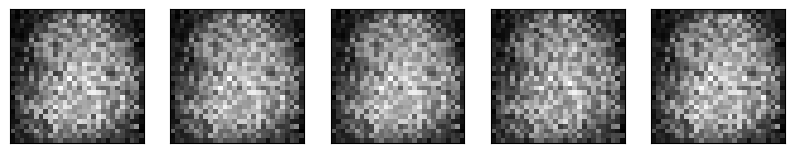

ÉPOCA 002 finalizada: custo discriminador 0.777621 - custo gerador 4.877354673743


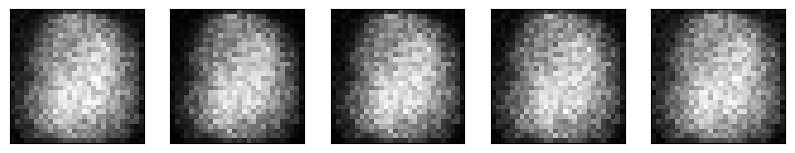

ÉPOCA 003 finalizada: custo discriminador 0.653490 - custo gerador 3.97854777186


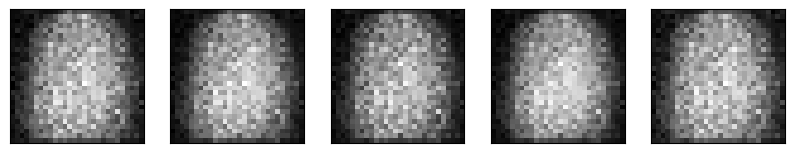

ÉPOCA 004 finalizada: custo discriminador 0.547118 - custo gerador 4.25688459783


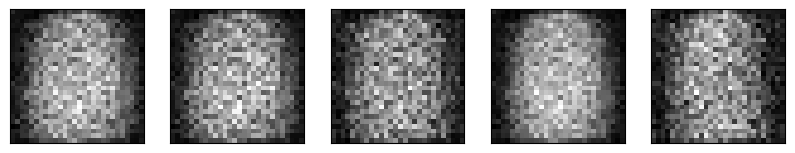

ÉPOCA 005 finalizada: custo discriminador 0.585714 - custo gerador 4.32793484635


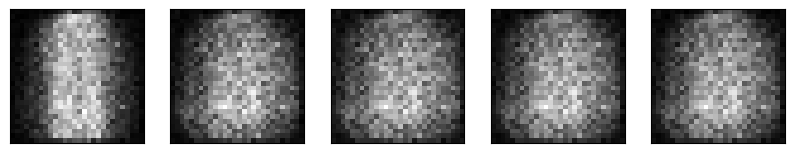

ÉPOCA 006 finalizada: custo discriminador 0.788215 - custo gerador 3.80611679020


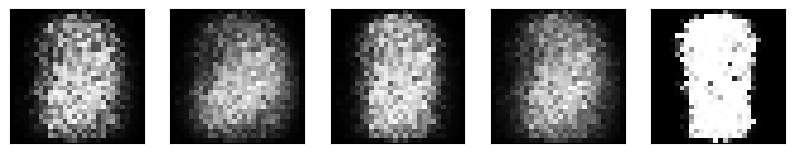

ÉPOCA 007 finalizada: custo discriminador 0.769354 - custo gerador 3.52991913134


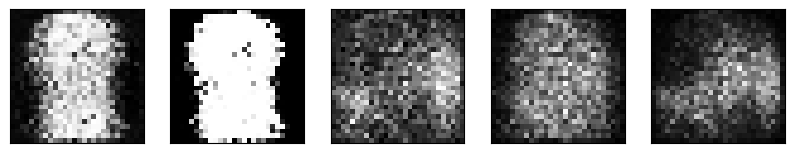

ÉPOCA 008 finalizada: custo discriminador 0.818574 - custo gerador 2.97050403780


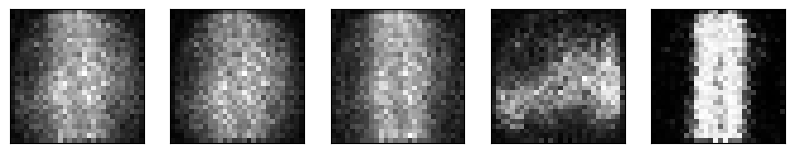

ÉPOCA 009 finalizada: custo discriminador 0.810530 - custo gerador 3.30500915893


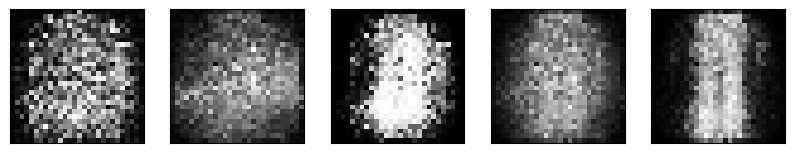

ÉPOCA 010 finalizada: custo discriminador 0.922900 - custo gerador 2.65321614388


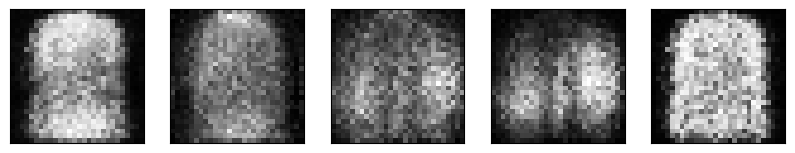

ÉPOCA 011 finalizada: custo discriminador 0.889312 - custo gerador 2.64881481252


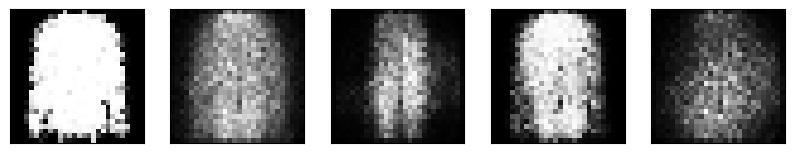

ÉPOCA 012 finalizada: custo discriminador 0.881911 - custo gerador 2.91637174441


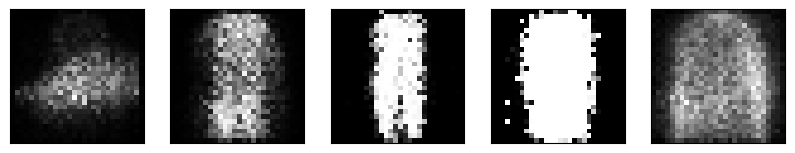

ÉPOCA 013 finalizada: custo discriminador 0.935070 - custo gerador 2.53796175201


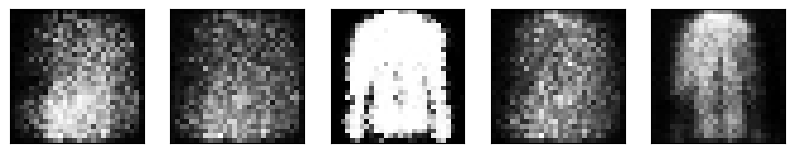

ÉPOCA 014 finalizada: custo discriminador 0.979106 - custo gerador 2.33092194832


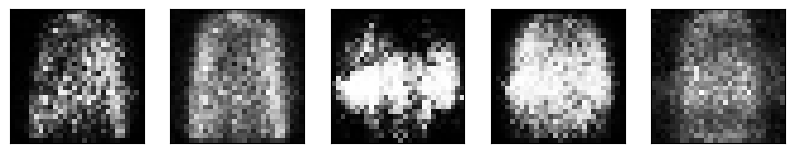

ÉPOCA 015 finalizada: custo discriminador 1.025174 - custo gerador 2.18864235885


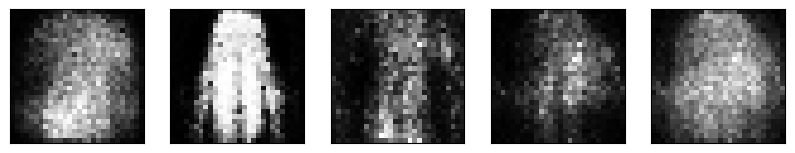

ÉPOCA 016 finalizada: custo discriminador 1.069931 - custo gerador 1.87764155359


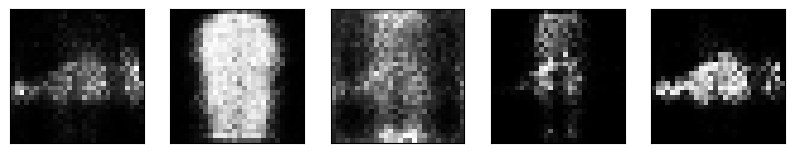

ÉPOCA 017 finalizada: custo discriminador 1.067243 - custo gerador 1.85536707278


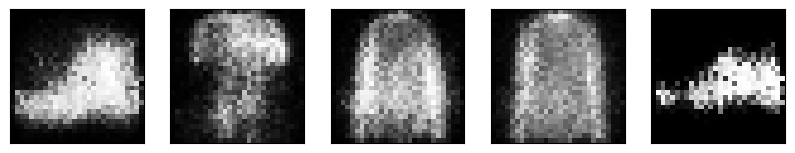

ÉPOCA 018 finalizada: custo discriminador 1.049772 - custo gerador 2.06947478049


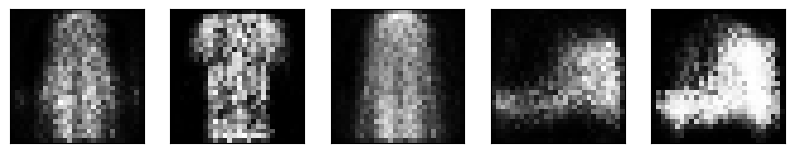

ÉPOCA 019 finalizada: custo discriminador 1.086876 - custo gerador 1.73221423393


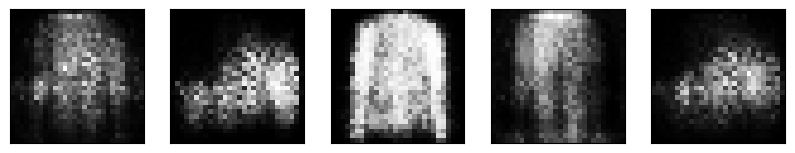

ÉPOCA 020 finalizada: custo discriminador 1.113026 - custo gerador 1.65651762722


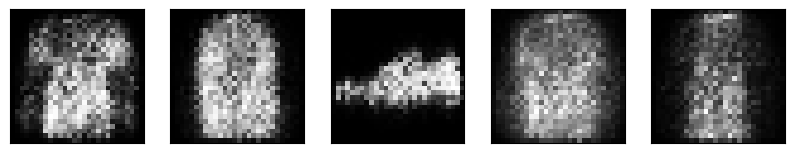

ÉPOCA 021 finalizada: custo discriminador 1.113575 - custo gerador 1.70048428662


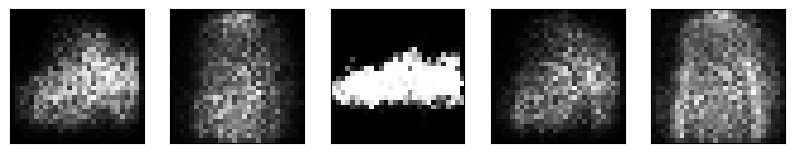

ÉPOCA 022 finalizada: custo discriminador 1.159747 - custo gerador 1.49623124630


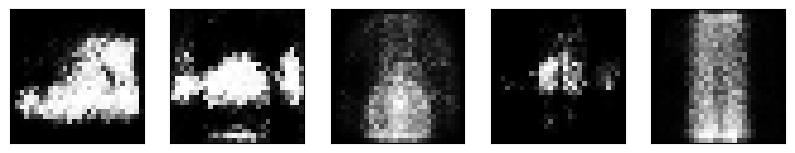

ÉPOCA 023 finalizada: custo discriminador 1.149442 - custo gerador 1.52972990137


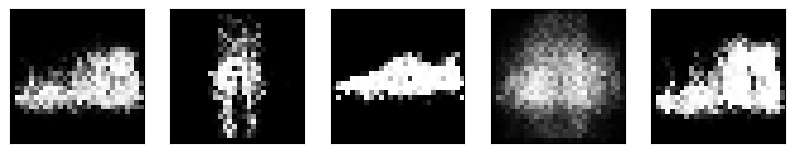

ÉPOCA 024 finalizada: custo discriminador 1.120152 - custo gerador 1.62558968356


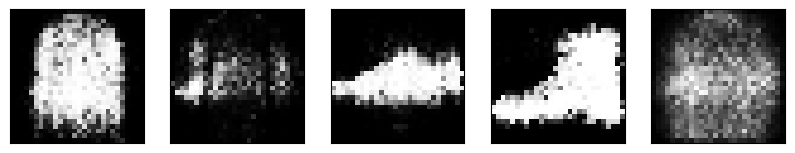

ÉPOCA 025 finalizada: custo discriminador 1.133908 - custo gerador 1.72444937724


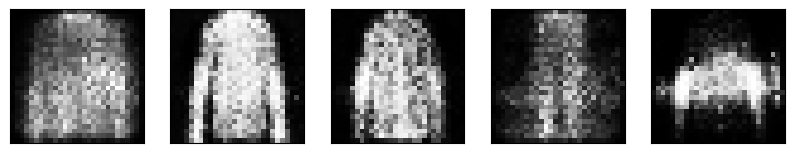

ÉPOCA 026 finalizada: custo discriminador 1.183596 - custo gerador 1.50285644152


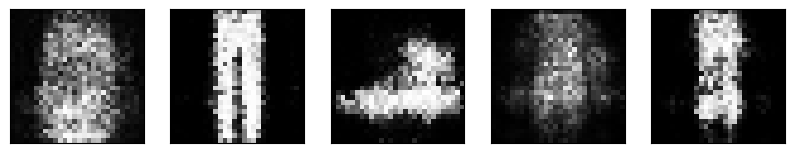

ÉPOCA 027 finalizada: custo discriminador 1.182376 - custo gerador 1.41792658431


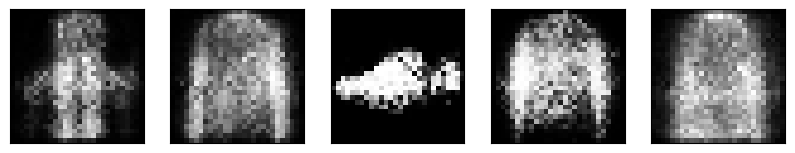

ÉPOCA 028 finalizada: custo discriminador 1.175885 - custo gerador 1.40980064075


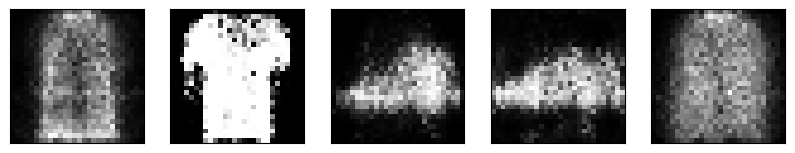

ÉPOCA 029 finalizada: custo discriminador 1.185448 - custo gerador 1.40615909468


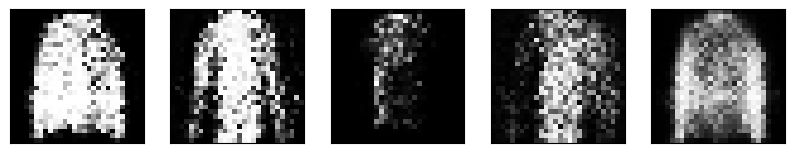

ÉPOCA 030 finalizada: custo discriminador 1.202878 - custo gerador 1.37771135436


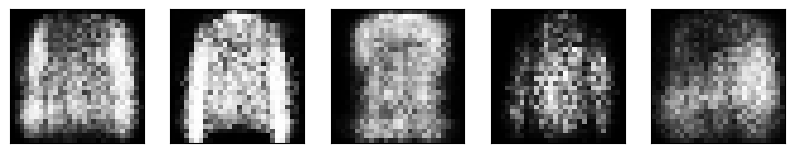

ÉPOCA 031 finalizada: custo discriminador 1.224722 - custo gerador 1.33089243153


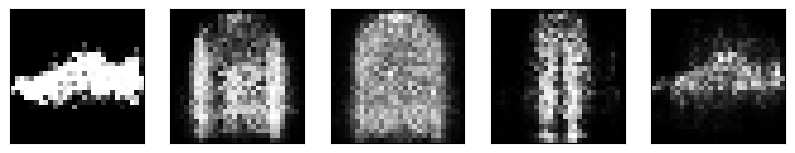

ÉPOCA 032 finalizada: custo discriminador 1.218889 - custo gerador 1.27511616661


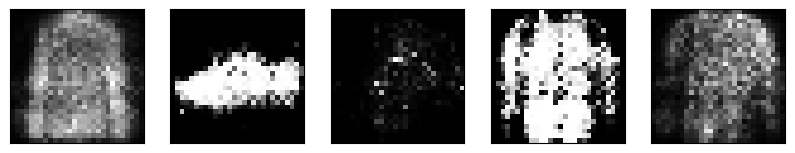

ÉPOCA 033 finalizada: custo discriminador 1.217342 - custo gerador 1.27497795998


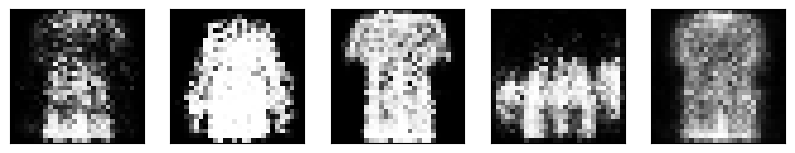

ÉPOCA 034 finalizada: custo discriminador 1.238480 - custo gerador 1.21343716179


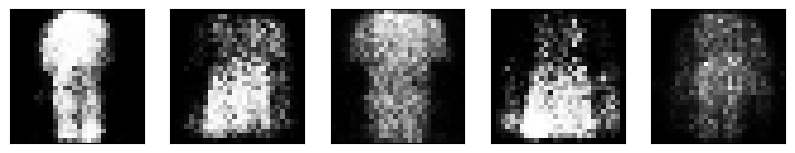

ÉPOCA 035 finalizada: custo discriminador 1.232513 - custo gerador 1.25944835370


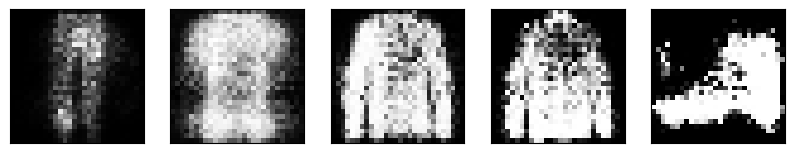

ÉPOCA 036 finalizada: custo discriminador 1.252631 - custo gerador 1.19453212196


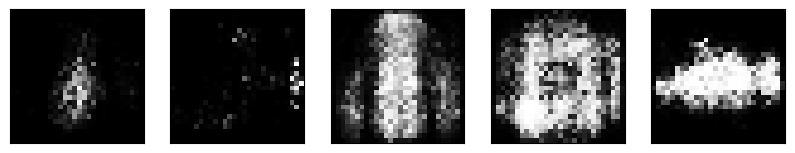

ÉPOCA 037 finalizada: custo discriminador 1.244041 - custo gerador 1.19104100348


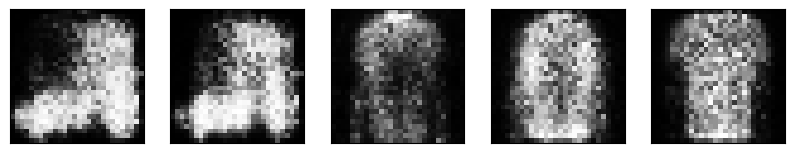

ÉPOCA 038 finalizada: custo discriminador 1.219909 - custo gerador 1.24740226083


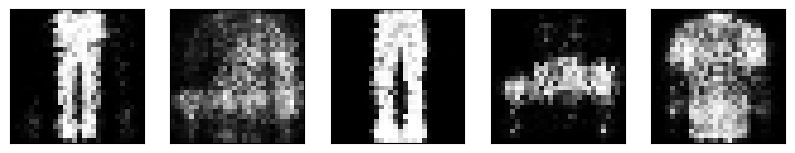

ÉPOCA 039 finalizada: custo discriminador 1.281146 - custo gerador 1.19534493816


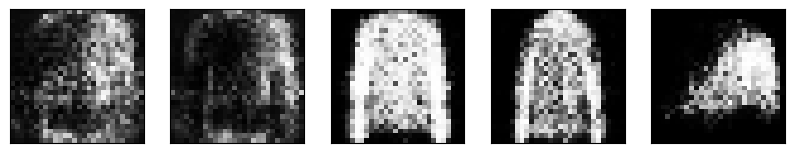

ÉPOCA 040 finalizada: custo discriminador 1.237312 - custo gerador 1.20925627694


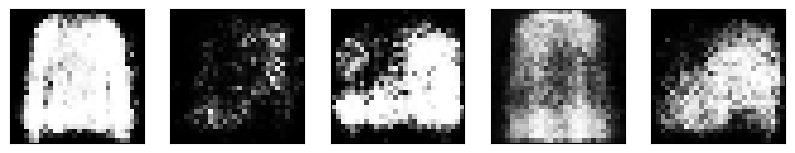

ÉPOCA 041 finalizada: custo discriminador 1.241005 - custo gerador 1.18024455425


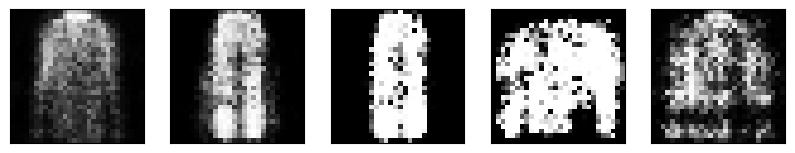

ÉPOCA 042 finalizada: custo discriminador 1.248353 - custo gerador 1.23507828206


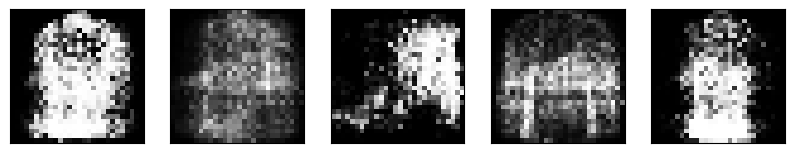

ÉPOCA 043 finalizada: custo discriminador 1.262403 - custo gerador 1.18815309240


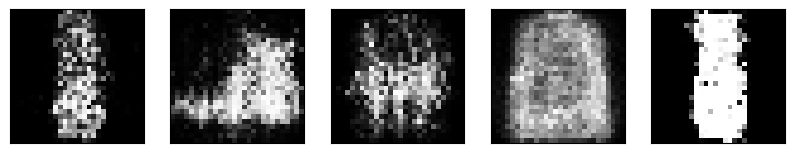

ÉPOCA 044 finalizada: custo discriminador 1.261231 - custo gerador 1.21761226596


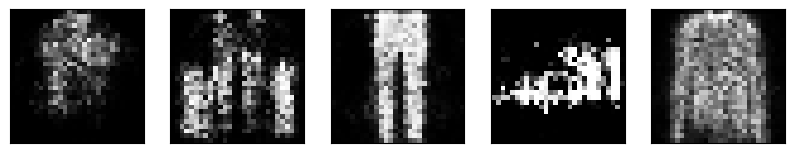

ÉPOCA 045 finalizada: custo discriminador 1.232609 - custo gerador 1.25761423225


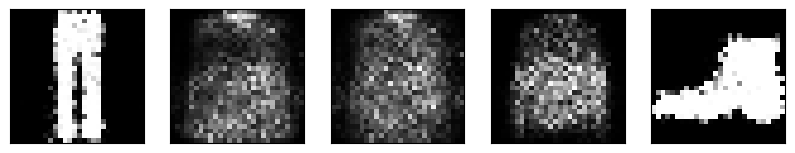

ÉPOCA 046 finalizada: custo discriminador 1.222327 - custo gerador 1.28813733066


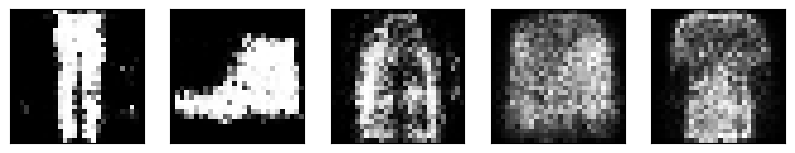

ÉPOCA 047 finalizada: custo discriminador 1.243387 - custo gerador 1.33227027250


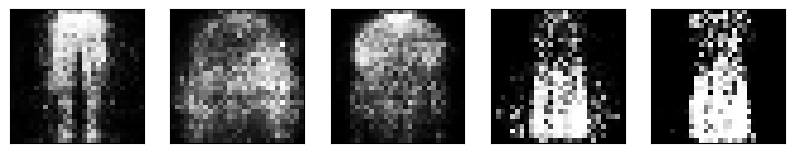

ÉPOCA 048 finalizada: custo discriminador 1.239837 - custo gerador 1.25079342238


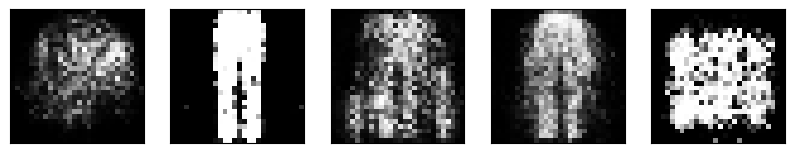

ÉPOCA 049 finalizada: custo discriminador 1.240637 - custo gerador 1.24586327554


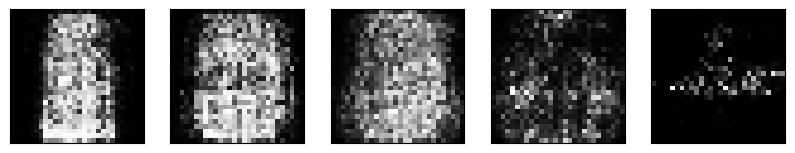

ÉPOCA 050 finalizada: custo discriminador 1.232628 - custo gerador 1.34260469309


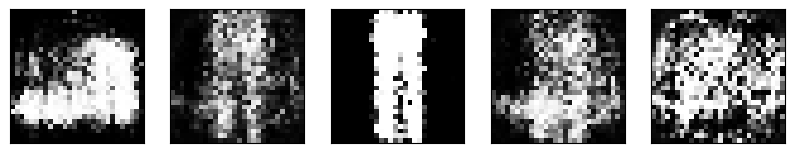

ÉPOCA 051 finalizada: custo discriminador 1.236810 - custo gerador 1.43004697031


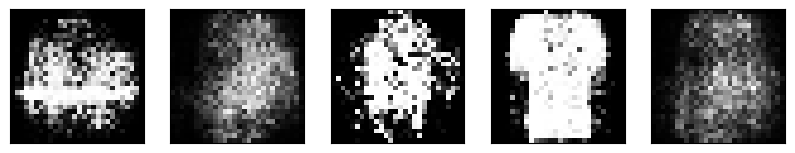

ÉPOCA 052 finalizada: custo discriminador 1.248171 - custo gerador 1.33367203918


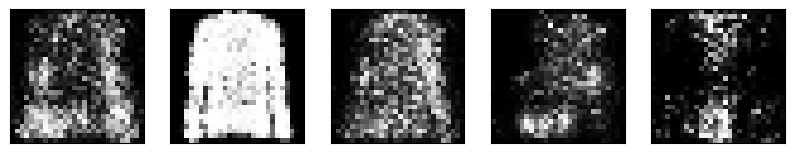

ÉPOCA 053 finalizada: custo discriminador 1.220209 - custo gerador 1.46731649045


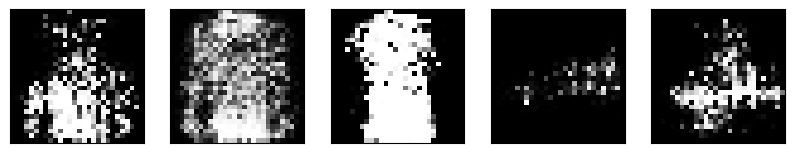

ÉPOCA 054 finalizada: custo discriminador 1.203273 - custo gerador 1.38654337259


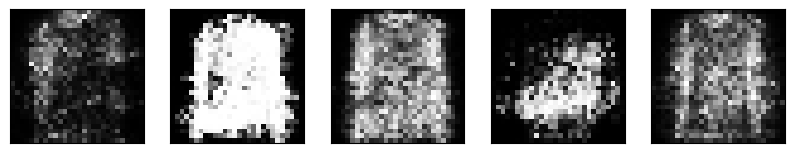

ÉPOCA 055 finalizada: custo discriminador 1.215201 - custo gerador 1.44288444383


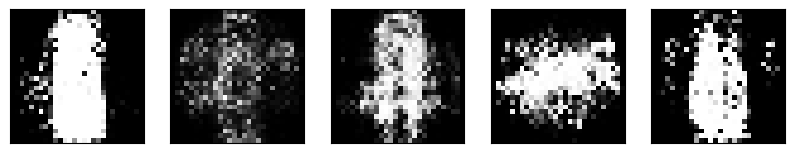

ÉPOCA 056 finalizada: custo discriminador 1.232140 - custo gerador 1.31638394618


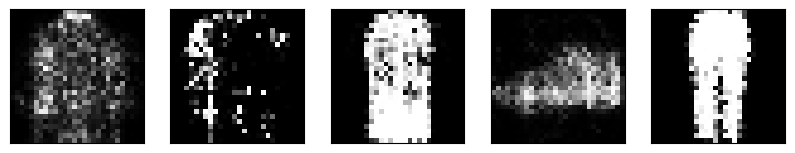

ÉPOCA 057 finalizada: custo discriminador 1.206598 - custo gerador 1.45059778581


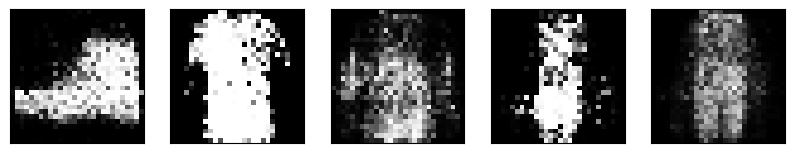

ÉPOCA 058 finalizada: custo discriminador 1.204425 - custo gerador 1.41487158769


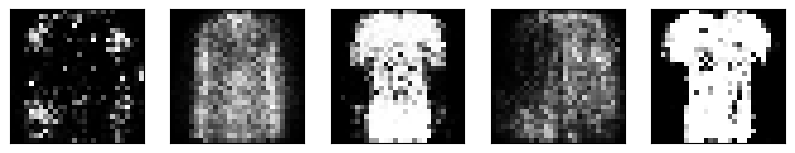

ÉPOCA 059 finalizada: custo discriminador 1.205122 - custo gerador 1.37615171477


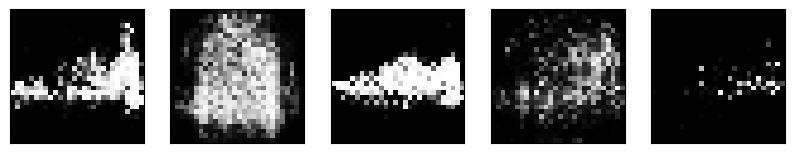

ÉPOCA 060 finalizada: custo discriminador 1.200651 - custo gerador 1.41698730366


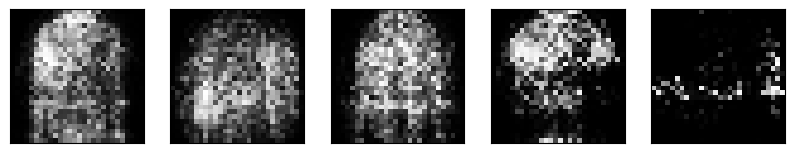

ÉPOCA 061 finalizada: custo discriminador 1.207417 - custo gerador 1.35495543142


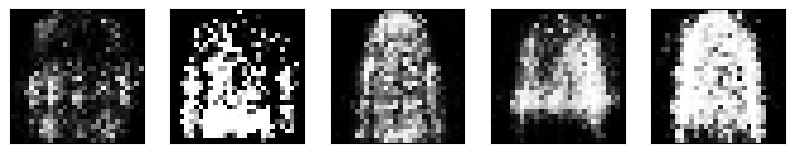

ÉPOCA 062 finalizada: custo discriminador 1.204778 - custo gerador 1.31494879898


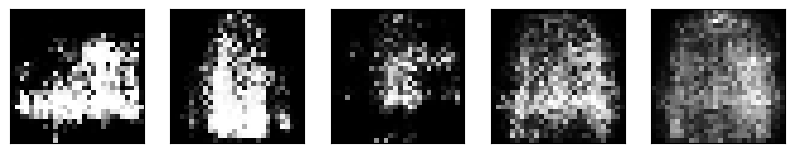

ÉPOCA 063 finalizada: custo discriminador 1.200482 - custo gerador 1.41743437093


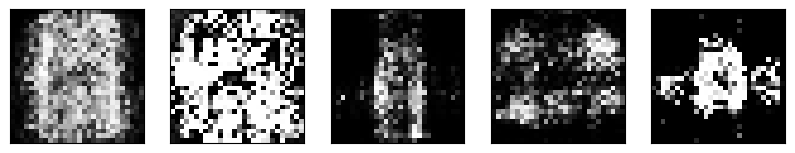

ÉPOCA 064 finalizada: custo discriminador 1.229859 - custo gerador 1.31922232161


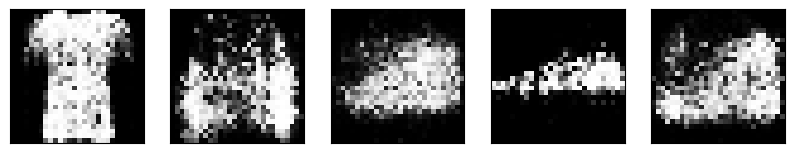

ÉPOCA 065 finalizada: custo discriminador 1.212995 - custo gerador 1.37824134975


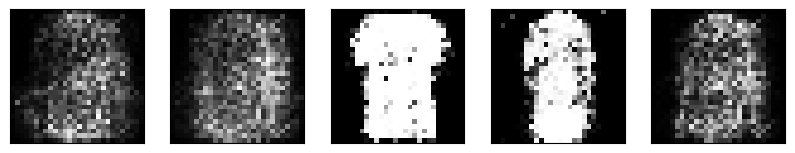

ÉPOCA 066 finalizada: custo discriminador 1.202380 - custo gerador 1.40155444401


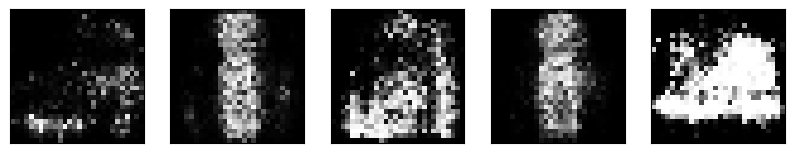

ÉPOCA 067 finalizada: custo discriminador 1.223405 - custo gerador 1.43942929383


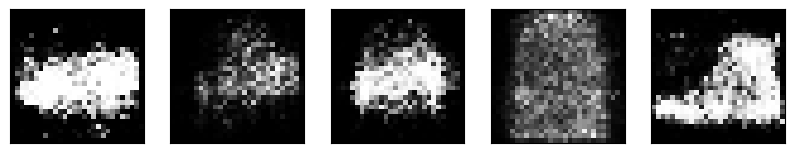

ÉPOCA 068 finalizada: custo discriminador 1.182807 - custo gerador 1.45489270268


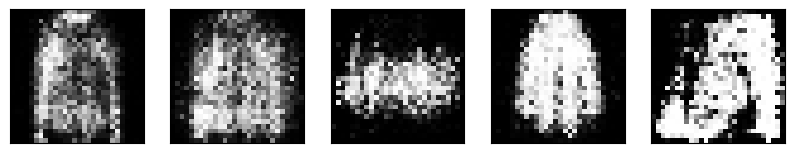

ÉPOCA 069 finalizada: custo discriminador 1.230128 - custo gerador 1.33035735352


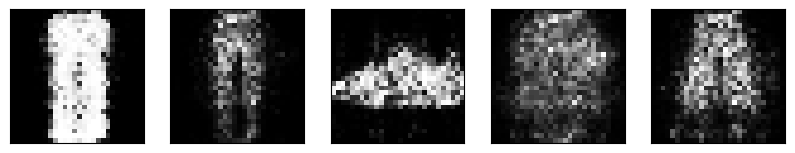

ÉPOCA 070 finalizada: custo discriminador 1.222040 - custo gerador 1.39695838715


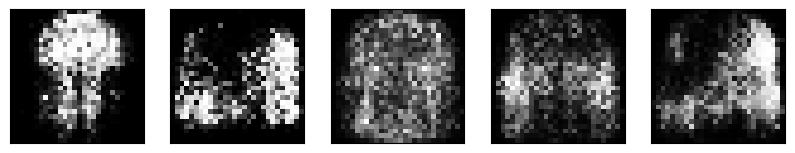

ÉPOCA 071 finalizada: custo discriminador 1.206743 - custo gerador 1.38229212045


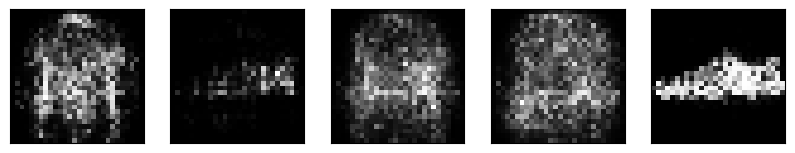

ÉPOCA 072 finalizada: custo discriminador 1.212350 - custo gerador 1.37259438932


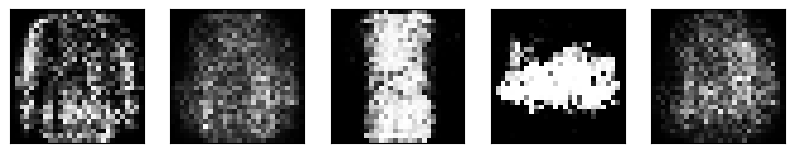

ÉPOCA 073 finalizada: custo discriminador 1.226638 - custo gerador 1.41298989305


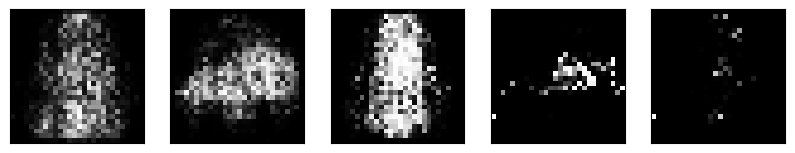

ÉPOCA 074 finalizada: custo discriminador 1.203999 - custo gerador 1.36434545886


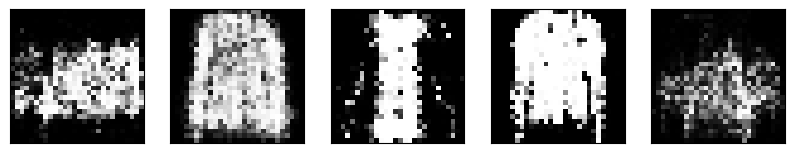

ÉPOCA 075 finalizada: custo discriminador 1.188261 - custo gerador 1.40126965865


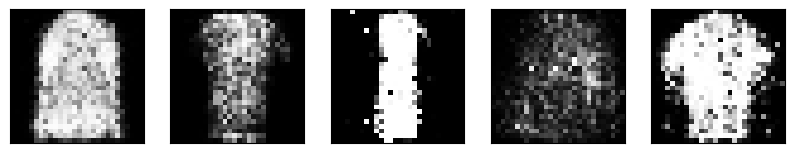

ÉPOCA 076 finalizada: custo discriminador 1.208636 - custo gerador 1.31690410926


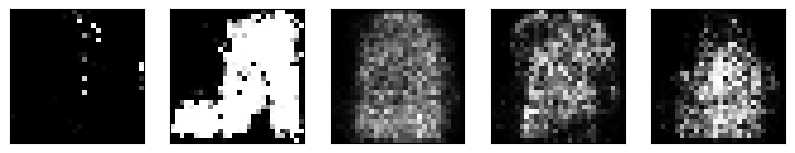

ÉPOCA 077 finalizada: custo discriminador 1.224331 - custo gerador 1.31075125860


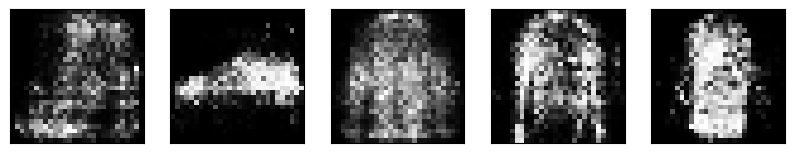

ÉPOCA 078 finalizada: custo discriminador 1.249394 - custo gerador 1.25190879988


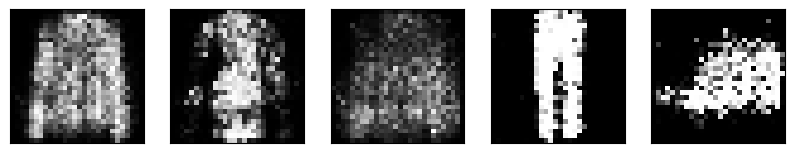

ÉPOCA 079 finalizada: custo discriminador 1.247215 - custo gerador 1.21765649742


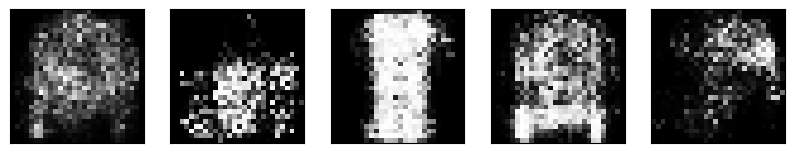

ÉPOCA 080 finalizada: custo discriminador 1.243860 - custo gerador 1.25774029841


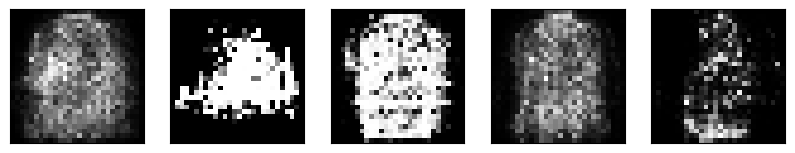

ÉPOCA 081 finalizada: custo discriminador 1.235455 - custo gerador 1.31492617694


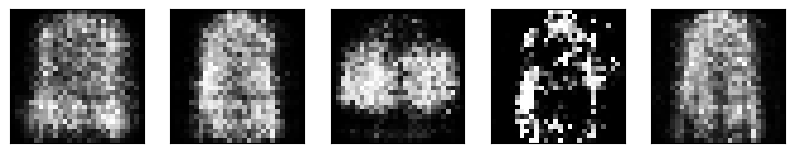

ÉPOCA 082 finalizada: custo discriminador 1.205578 - custo gerador 1.33063216094


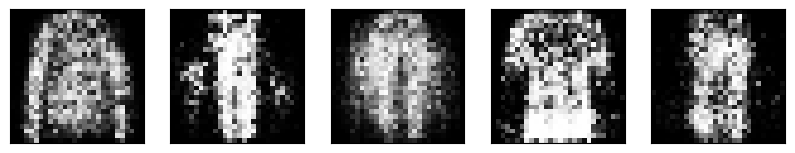

ÉPOCA 083 finalizada: custo discriminador 1.226056 - custo gerador 1.29891012563


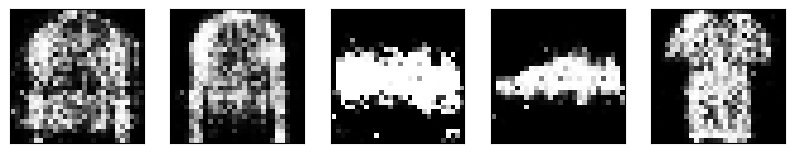

ÉPOCA 084 finalizada: custo discriminador 1.238039 - custo gerador 1.29783968459


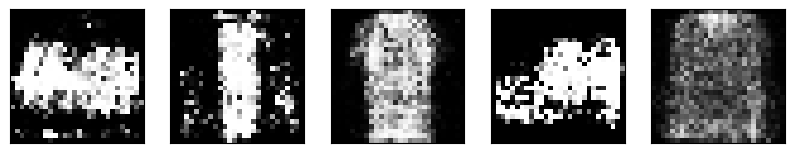

ÉPOCA 085 finalizada: custo discriminador 1.217503 - custo gerador 1.31589538462


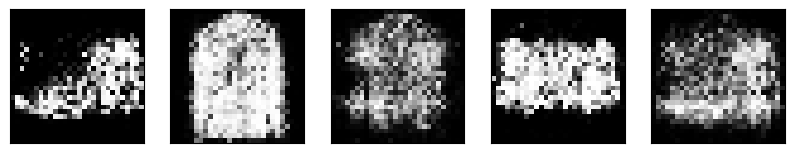

ÉPOCA 086 finalizada: custo discriminador 1.223037 - custo gerador 1.27371118542


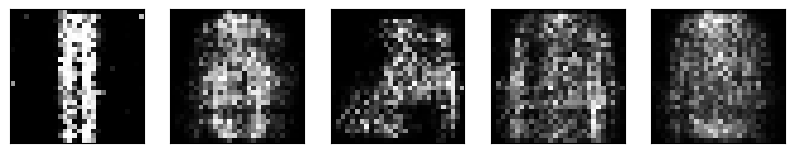

ÉPOCA 087 finalizada: custo discriminador 1.212649 - custo gerador 1.30343207818


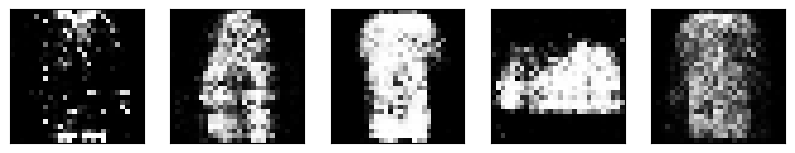

ÉPOCA 088 finalizada: custo discriminador 1.240267 - custo gerador 1.29268808436


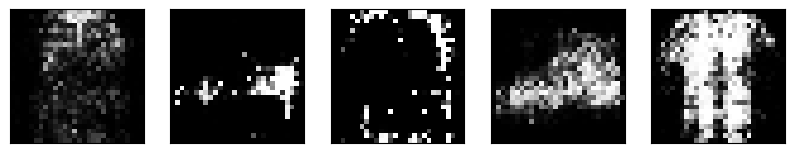

ÉPOCA 089 finalizada: custo discriminador 1.242157 - custo gerador 1.26376568014


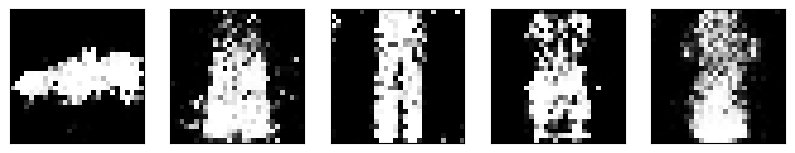

ÉPOCA 090 finalizada: custo discriminador 1.227139 - custo gerador 1.21816222512


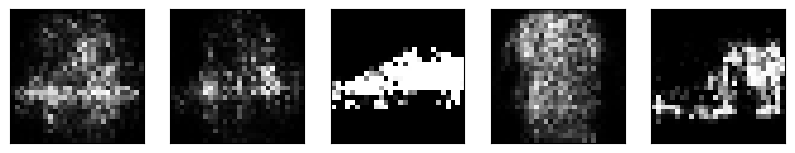

ÉPOCA 091 finalizada: custo discriminador 1.209707 - custo gerador 1.30626699255


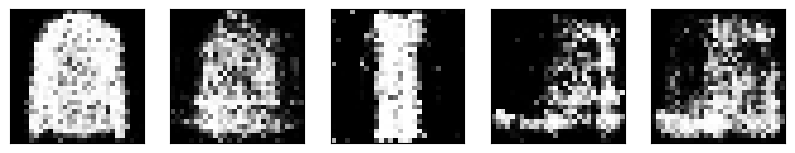

ÉPOCA 092 finalizada: custo discriminador 1.222271 - custo gerador 1.28637745257


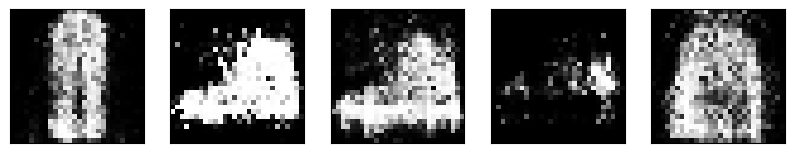

ÉPOCA 093 finalizada: custo discriminador 1.225664 - custo gerador 1.31006436257


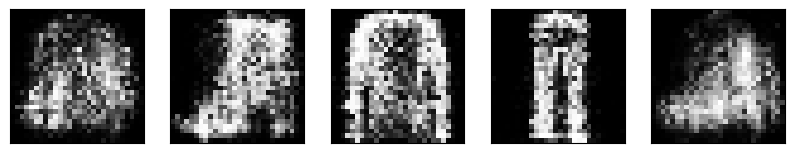

ÉPOCA 094 finalizada: custo discriminador 1.252180 - custo gerador 1.24155514829


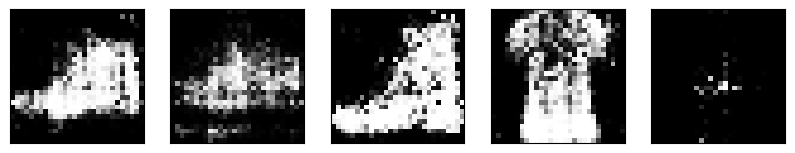

ÉPOCA 095 finalizada: custo discriminador 1.234959 - custo gerador 1.24814720826


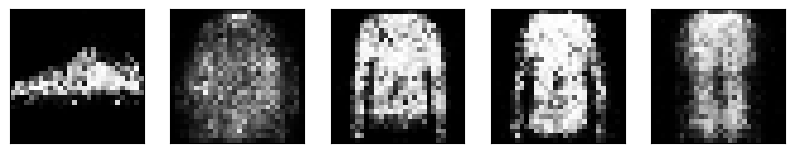

ÉPOCA 096 finalizada: custo discriminador 1.249254 - custo gerador 1.21451504774


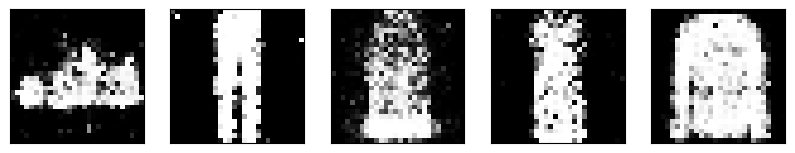

ÉPOCA 097 finalizada: custo discriminador 1.235326 - custo gerador 1.21474118348


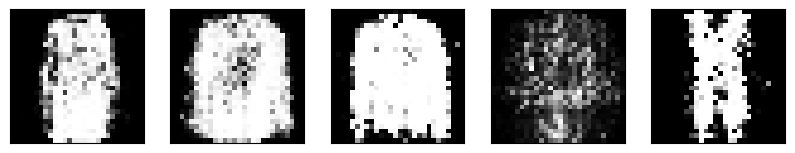

ÉPOCA 098 finalizada: custo discriminador 1.236613 - custo gerador 1.23008934243


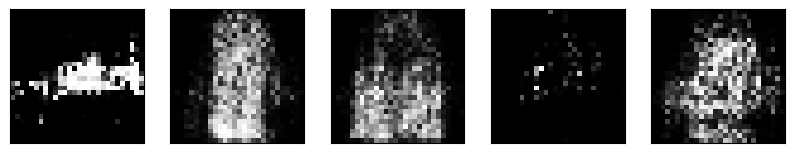

ÉPOCA 099 finalizada: custo discriminador 1.249118 - custo gerador 1.24705007923


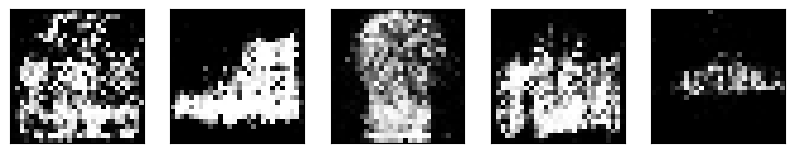

ÉPOCA 100 finalizada: custo discriminador 1.246608 - custo gerador 1.19109738049


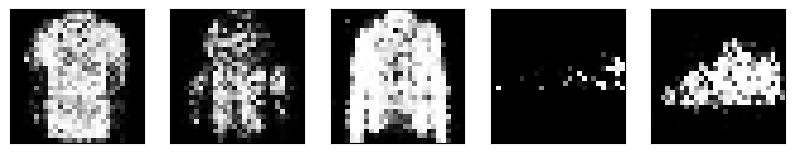

In [10]:
historico_D = []
historico_G = []

# Inicia o grande loop de 100 épocas. Cada época é uma passada completa por todas as imagens.
for epoch in range(100):
    D_running_loss = 0 # Acumula o erro do Discriminador para mostrar a média depois
    G_running_loss = 0 # Acumula o erro do Gerador para mostrar a média depois

    # Itera sobre os lotes (batches) de 256 imagens vindos do FashionMNIST
    for i, (imagens_reais, _) in enumerate(train_loader):
        batch_size = imagens_reais.size(0)
        
        # Normalização: As imagens vêm de [0, 1]. Como o Gerador usa Tanh, 
        # transformamos para [-1, 1] para que fiquem na mesma escala.
        imagens_reais = imagens_reais * 2 - 1
        imagens_reais = imagens_reais.to(device)

        
        # Treinamento do gerador

        # -------------------------------------------------------------------
        # 1. TREINAMENTO DO GERADOR (O Falsificador tenta aprender)
        # -------------------------------------------------------------------
        G_optimizer.zero_grad() # Reseta os cálculos de gradiente anteriores
        
        # Cria um ruído aleatório de 100 números para cada imagem do lote
        ruido = np.random.uniform(low=-1., high=1., size=(batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device)
        
        imagens_falsas = G.forward(ruido)    # Gerador cria as imagens "fake"
        outputs_falsas = D.forward(imagens_falsas) # O Juiz (D) dá a nota
        
        # TRUQUE: O Gerador quer que o Juiz dê nota 1 (Real). 
        # Criamos rótulos "1" para as imagens falsas para calcular o quanto o D foi enganado.
        labels_falsas = torch.ones(batch_size).to(device)
        G_loss = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)
        
        G_loss.backward()  # Calcula como mudar os pesos do Gerador para enganar melhor o D
        G_optimizer.step() # Atualiza o Gerador


        # Treinamento do discriminador       
        # -------------------------------------------------------------------
        # 2. TREINAMENTO DO DISCRIMINADOR (O Detetive tenta aprender)
        # -------------------------------------------------------------------
        D_optimizer.zero_grad()
        
        # PARTE A: O quão bem ele identifica as imagens REAIS (Deseja nota 1)
        outputs_reais = D.forward(imagens_reais)
        # Label Smoothing (0.9): Ajuda o D a não ser arrogante e facilita o treino
        labels_reais = (torch.ones(batch_size) * 0.9).to(device)
        D_loss_reais = criterion(outputs_reais.view(*labels_reais.shape), labels_reais)

        # PARTE B: O quão bem ele identifica as imagens FALSAS (Deseja nota 0)
        # Geramos novas fakes para que o D não aprenda em cima de gradientes velhos
        ruido = np.random.uniform(-1., 1., (batch_size, 100))
        ruido = torch.from_numpy(ruido).float().to(device)
        imagens_falsas = G.forward(ruido)
        
        outputs_falsas = D.forward(imagens_falsas)
        labels_falsas = torch.zeros(batch_size).to(device) # Para estas, o rótulo é 0
        D_loss_falsas = criterion(outputs_falsas.view(*labels_falsas.shape), labels_falsas)

        # Erro total: Soma do acerto nas reais + acerto nas falsas
        D_loss = D_loss_reais + D_loss_falsas
        D_loss.backward()  # Calcula como o D pode ser um detetive melhor
        D_optimizer.step() # Atualiza o Discriminador

        D_running_loss += D_loss.item()
        G_running_loss += G_loss.item()


        # Imprimindo os dados referentes a esse batch  
        # Imprime o progresso em tempo real dentro da época
        print('\rÉpoca {:03d} - Loop {:3d} de {:3d}: custo discriminador {:03.5f} - custo gerador {:03.5f}'.format(epoch + 1,
                                                                                                                   i + 1,
                                                                                                                   len(train_loader),
                                                                                                                   D_loss.item(),
                                                                                                                   G_loss.item()), 
                                                                                                                 end = '\r')
    # Imprimindo os dados referentes a essa época
    # Ao final da época, calcula as médias e mostra 5 resultados visuais do Gerador
    D_running_loss /= len(train_loader)
    G_running_loss /= len(train_loader)
    print('ÉPOCA {:03d} finalizada: custo discriminador {:03.6f} - custo gerador {:03.6f}'.format(epoch + 1, 
                                                                                                  D_running_loss,
                                                                                                  G_running_loss))
    # Guardando as médias para o gráfico
    historico_D.append(D_running_loss)
    historico_G.append(G_running_loss)
    
    # Plota o progresso visual da IA
    fig, ax = plt.subplots(1, 5, figsize=(10,5))
    for i in range(5):
      ax[i].imshow(imagens_falsas.cpu().detach().numpy()[i].reshape(28, 28), cmap='gray')
      #ax[i].axis('off') # Remove os eixos para ficar mais limpo
      ax[i].xaxis.set_visible(False)
      ax[i].yaxis.set_visible(False)    
    plt.show()
    

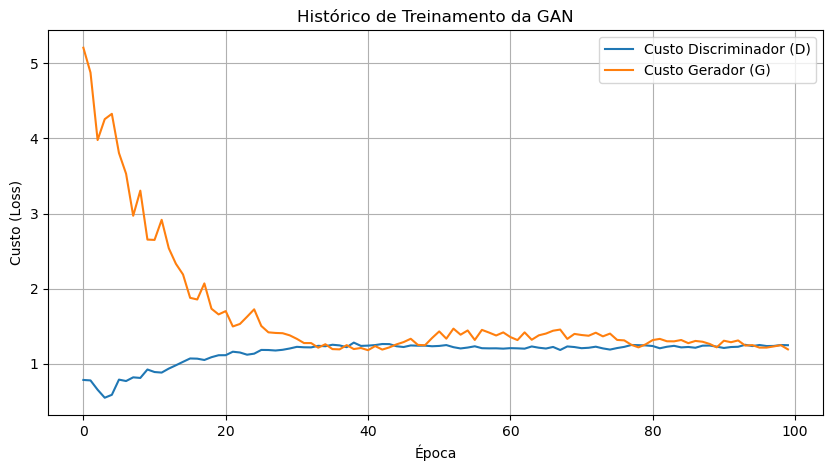

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(historico_D, label='Custo Discriminador (D)')
plt.plot(historico_G, label='Custo Gerador (G)')
plt.title('Histórico de Treinamento da GAN')
plt.xlabel('Época')
plt.ylabel('Custo (Loss)')
plt.legend()
plt.grid(True)
plt.show()

🔍 O que observar no gráfico real:

Equilíbrio: Diferente de uma rede neural comum onde o erro deve chegar próximo de zero, em uma GAN o ideal é que os dois custos fiquem oscilando. Se o D_loss cair para zero, o Discriminador ficou perfeito demais e o Gerador não consegue mais aprender (o gradiente desaparece).

Overfitting do Discriminador: Se a linha do Discriminador cair muito e a do Gerador subir sem parar, o Discriminador "decorou" as imagens reais. O Label Smoothing (0.9) que usamos
serve justamente para evitar que isso aconteça rápido demais!

Mode Collapse: Se o erro do Gerador ficar muito baixo mas as imagens geradas forem todas iguais, ele encontrou um "atalho" e parou de diversificar.

## Etapa 7: Criação de novas imagens

Comando é o ponto de partida para a "criatividade" da nosa Inteligência Artificial. Em termos simples, ela gera a matéria-prima aleatória que o Gerador usará para esculpir uma imagem.

In [14]:
# np.random.uniform: Gera números aleatórios seguindo uma distribuição uniforme
# (todos os números no intervalo têm a mesma chance de serem escolhidos).
#
# -1. : O valor mínimo (limite inferior).
#  1. : O valor máximo (limite superior).
#
# (20, 100): O formato (shape) da matriz resultante.
#    - 20: É o número de amostras (neste caso, nós estamos criando 20 "sementes" de imagens).
#    - 100: É o tamanho do vetor de ruído (o espaço latente). Cada uma das 20 imagens 
#           será gerada a partir de 100 números aleatórios diferentes.
ruido = np.random.uniform(-1., 1., (20, 100))

In [13]:
ruido[1]

array([ 0.87650027,  0.12818217,  0.20424207, -0.70760615, -0.02488827,
        0.64101312, -0.62266414,  0.55448454, -0.03571798, -0.32348009,
        0.25154178,  0.86793104, -0.9767418 , -0.73500417, -0.41454137,
       -0.26225174, -0.51149261, -0.71535155,  0.10849108, -0.71707615,
        0.16023531,  0.67060619,  0.52395062, -0.41853177,  0.39310859,
        0.25954577,  0.3671129 , -0.37708316, -0.99741981, -0.99959186,
       -0.564283  , -0.24682219,  0.83539329, -0.24058127,  0.09736451,
        0.70070913,  0.40983945, -0.94324758,  0.37104964,  0.78500286,
        0.77027297,  0.38221126, -0.11600681, -0.21162165,  0.10466691,
        0.42051191,  0.14248616,  0.78915212,  0.13474893, -0.04988192,
       -0.76749438, -0.37083552,  0.8018141 , -0.10149613,  0.74342266,
       -0.76741453,  0.56904383, -0.35115236, -0.5481469 , -0.25921268,
       -0.57927008, -0.73288493,  0.1474351 , -0.17256851, -0.51970254,
       -0.55511728,  0.09414463,  0.26106975, -0.73787936,  0.39

In [15]:
# torch.from_numpy(ruido):
# Transforma a matriz do NumPy (criada com np.random.uniform) em um Tensor do PyTorch.
# O PyTorch não consegue processar arrays do NumPy diretamente; ele precisa desse formato.

# .float():
# Garante que os números sejam do tipo "ponto flutuante de 32 bits" (float32).
# Redes neurais no PyTorch quase sempre esperam float32 para realizar os cálculos.

# .to(device):
# Envia os dados para o hardware correto (geralmente a GPU 'cuda').
# Lembre-se: se a sua rede neural (G e D) está na GPU, os dados (ruido)
# também precisam estar nela. Se um estiver na CPU e o outro na GPU, o código dará erro.

ruido = torch.from_numpy(ruido).float().to(device)

In [16]:
type(ruido)

torch.Tensor

In [17]:
# G.eval():
# Coloca o Gerador no "Modo de Avaliação" (Evaluation Mode).
# Isso avisa ao PyTorch para DESATIVAR o Dropout (que se definiu na classe).
# No treino, o Dropout ajuda a aprender, mas na hora de gerar a imagem final, 
# queremos que todos os neurônios trabalhem juntos para dar o melhor resultado possível.
G.eval()

# previsao = G.forward(ruido):
# É o momento da criação! O Gerador recebe os 100 números aleatórios (ruido)
# e os passa por todas as suas camadas densas até transformar em uma imagem.
# O resultado 'previsao' conterá os 784 pixels (28x28) das imagens geradas.
previsao = G.forward(ruido)

In [18]:
# .cpu():
# Traz os dados da memória da placa de vídeo (GPU/CUDA) de volta para a memória do computador (CPU).
# Bibliotecas de visualização como o Matplotlib não conseguem acessar dados que estão "presos" na GPU.

# .detach():
# Corta a conexão do tensor com o "grafo de gradientes". 
# Durante o treino, o PyTorch rastreia tudo o que acontece para poder calcular o erro depois. 
# Como agora só queremos ver a imagem e não vamos mais treinar, o .detach() "liberta" o dado
# desse rastreamento, economizando memória e evitando erros.

# .numpy():
# Converte o Tensor do PyTorch em uma matriz do NumPy. 
# O NumPy é o padrão ouro para manipulação de imagens e gráficos em Python.

previsao = previsao.cpu().detach().numpy()

In [19]:
previsao.shape[0]

20

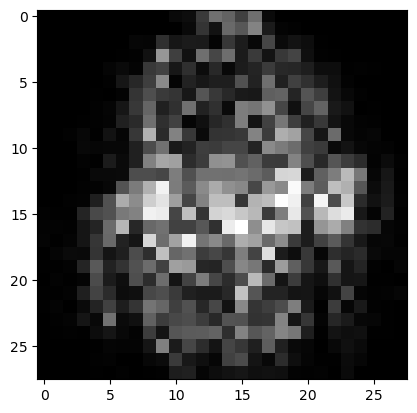

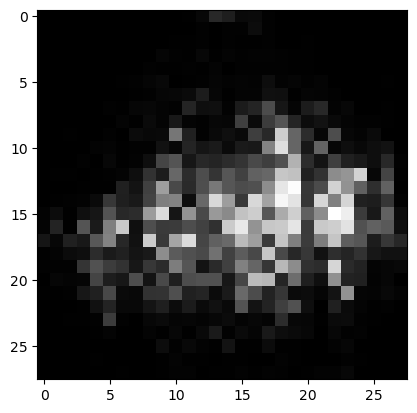

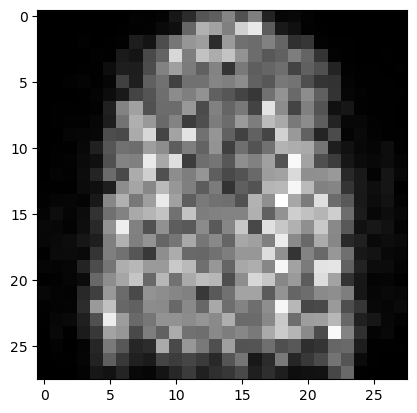

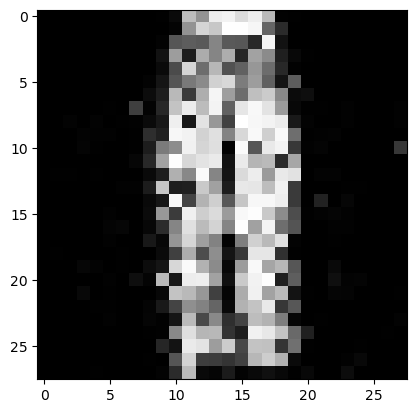

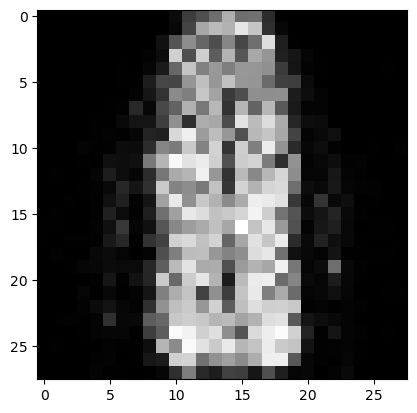

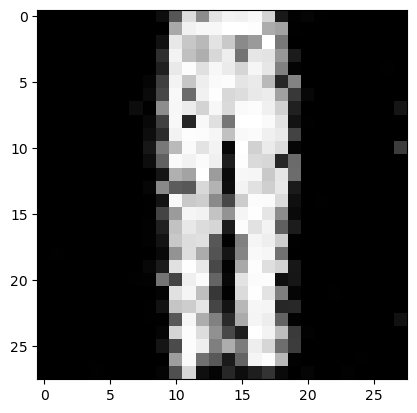

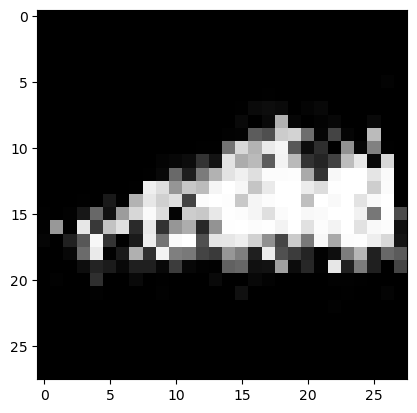

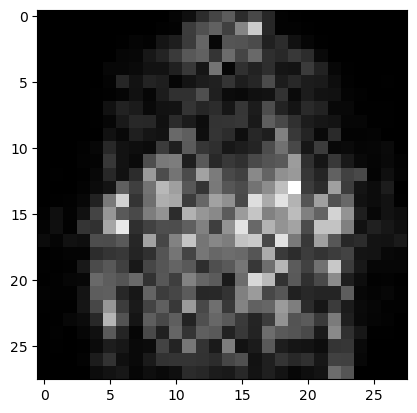

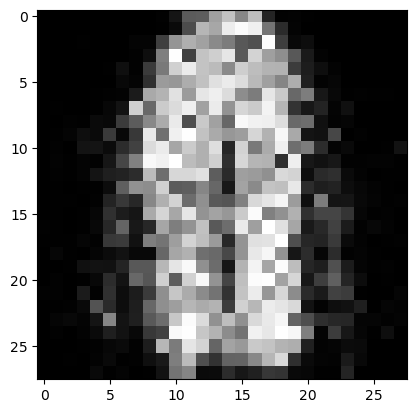

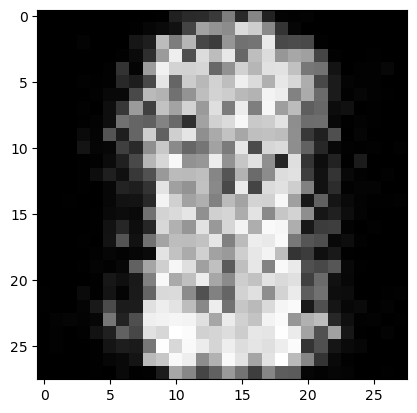

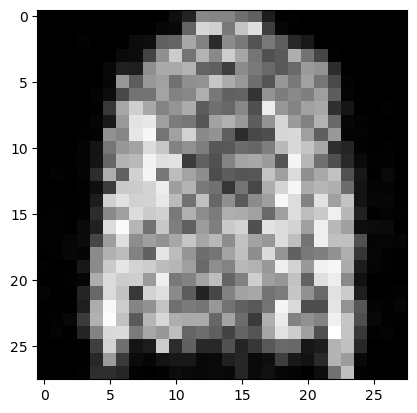

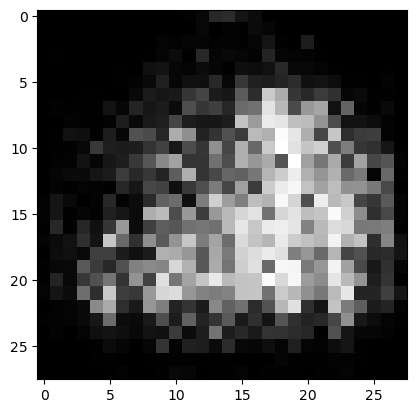

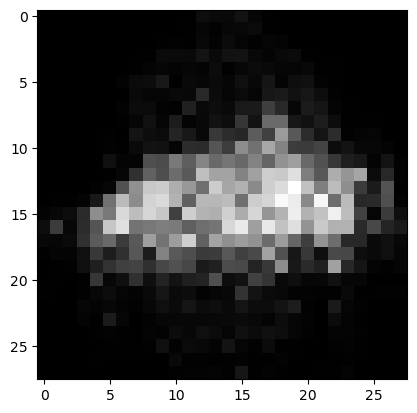

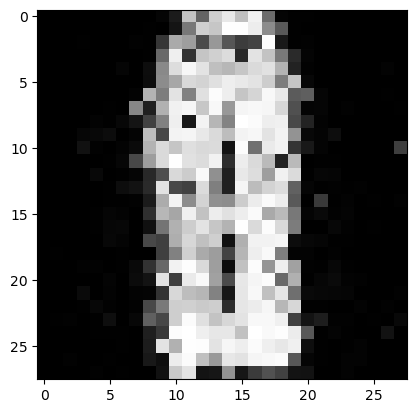

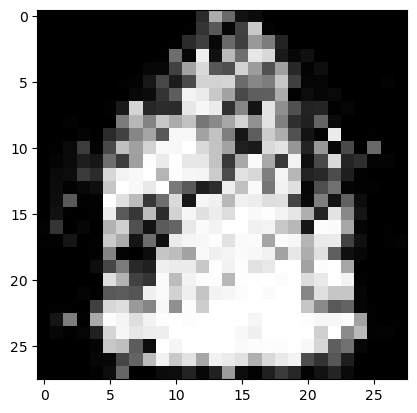

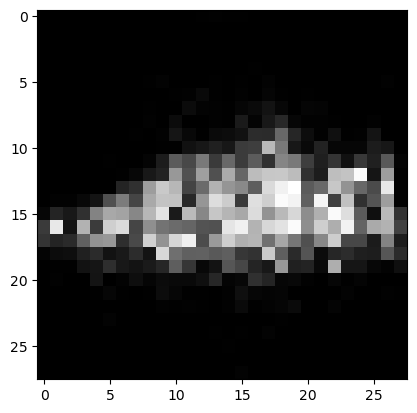

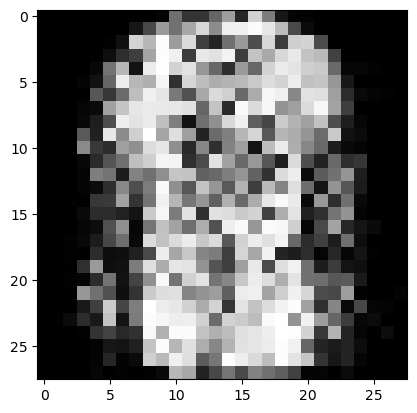

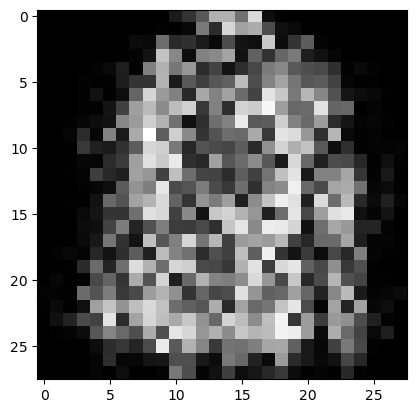

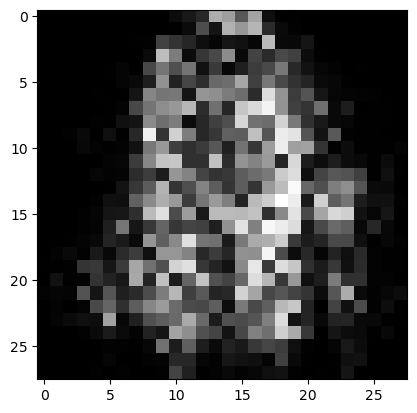

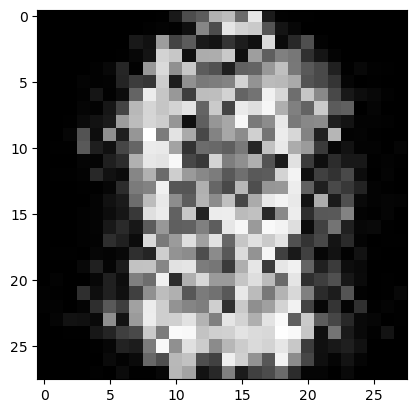

In [20]:
for i in range(previsao.shape[0]):
  plt.imshow(previsao[i, :].squeeze(), cmap='gray')
  plt.show()

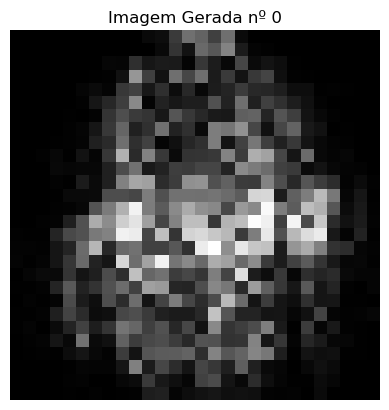

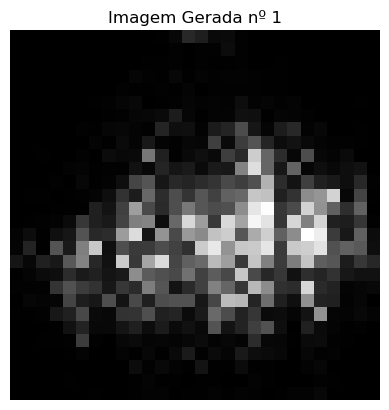

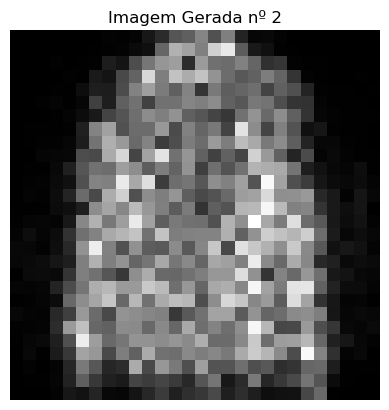

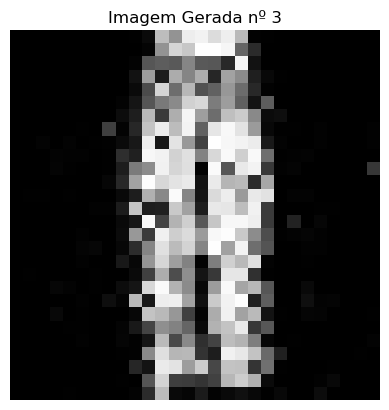

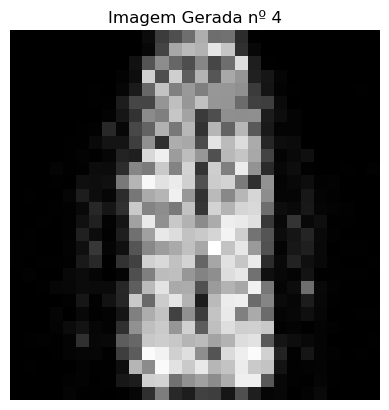

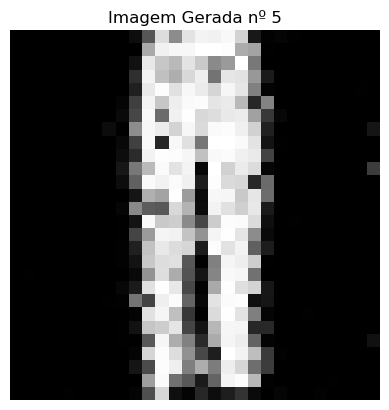

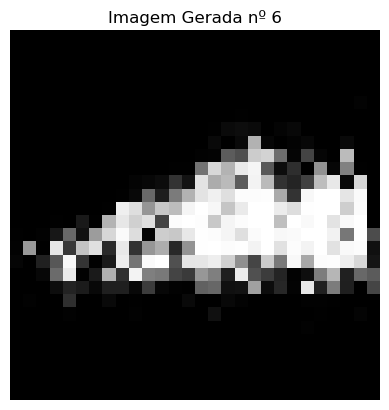

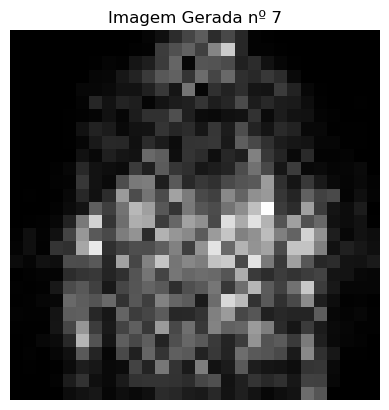

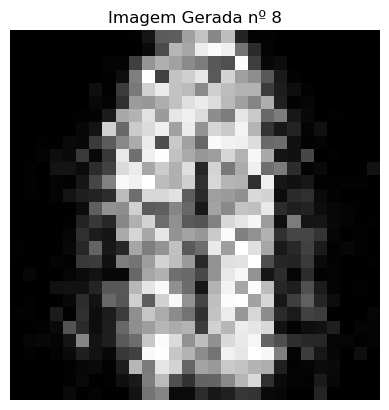

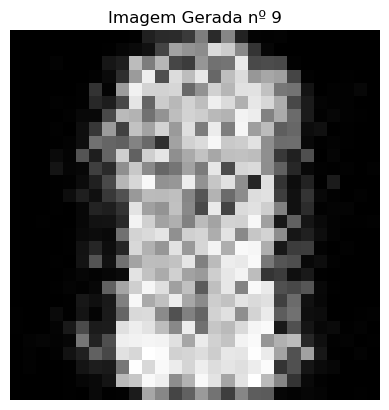

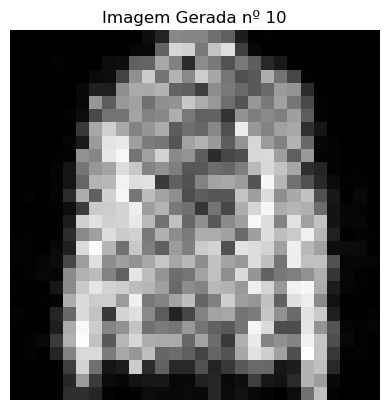

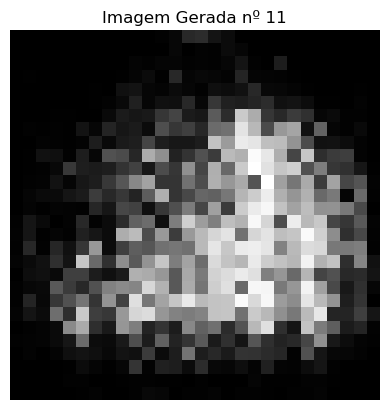

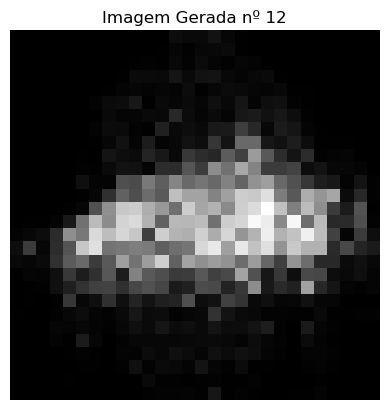

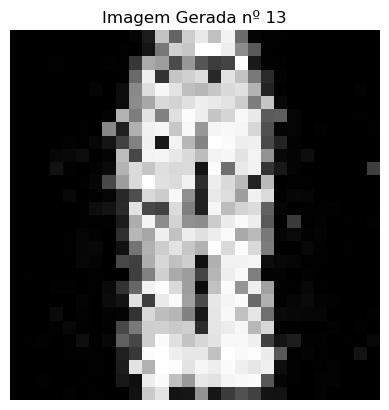

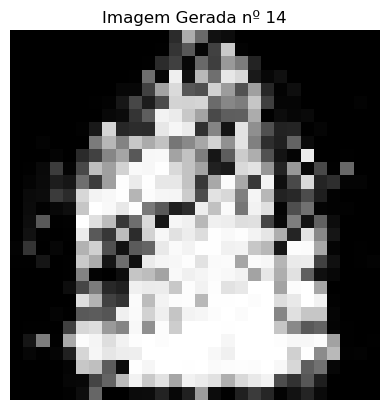

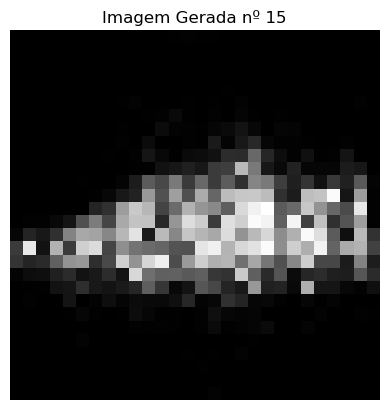

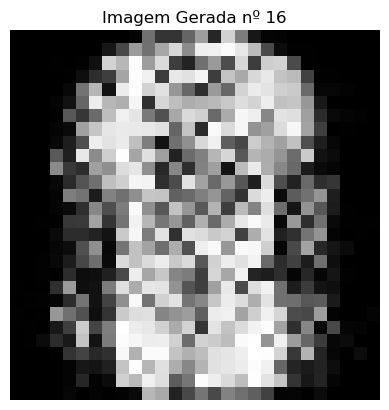

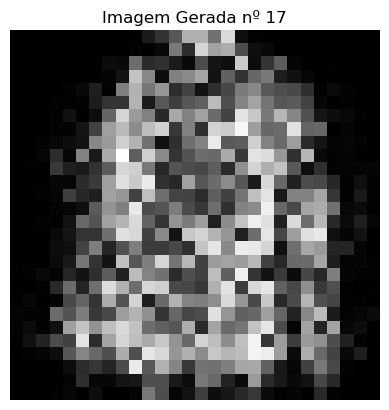

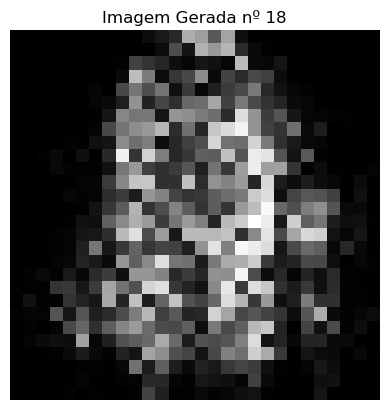

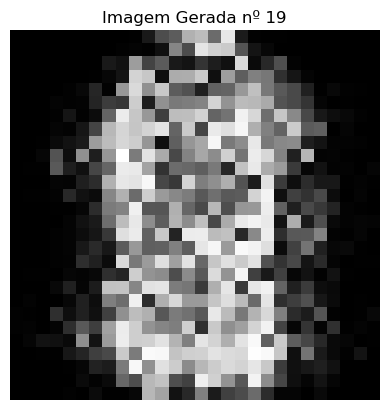

In [21]:
nomes_categorias = [
    "Camiseta", "Calça", "Suéter", "Vestido", "Casaco", 
    "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"
]

# Se estiver percorrendo previsões do Gerador:
for i in range(previsao.shape[0]):
    plt.imshow(previsao[i, :].squeeze(), cmap='gray')
    
    # Adiciona o título no gráfico
    plt.title(f"Imagem Gerada nº {i}") 
    
    plt.axis('off') # Remove as bordas com números para ficar mais bonito
    plt.show()

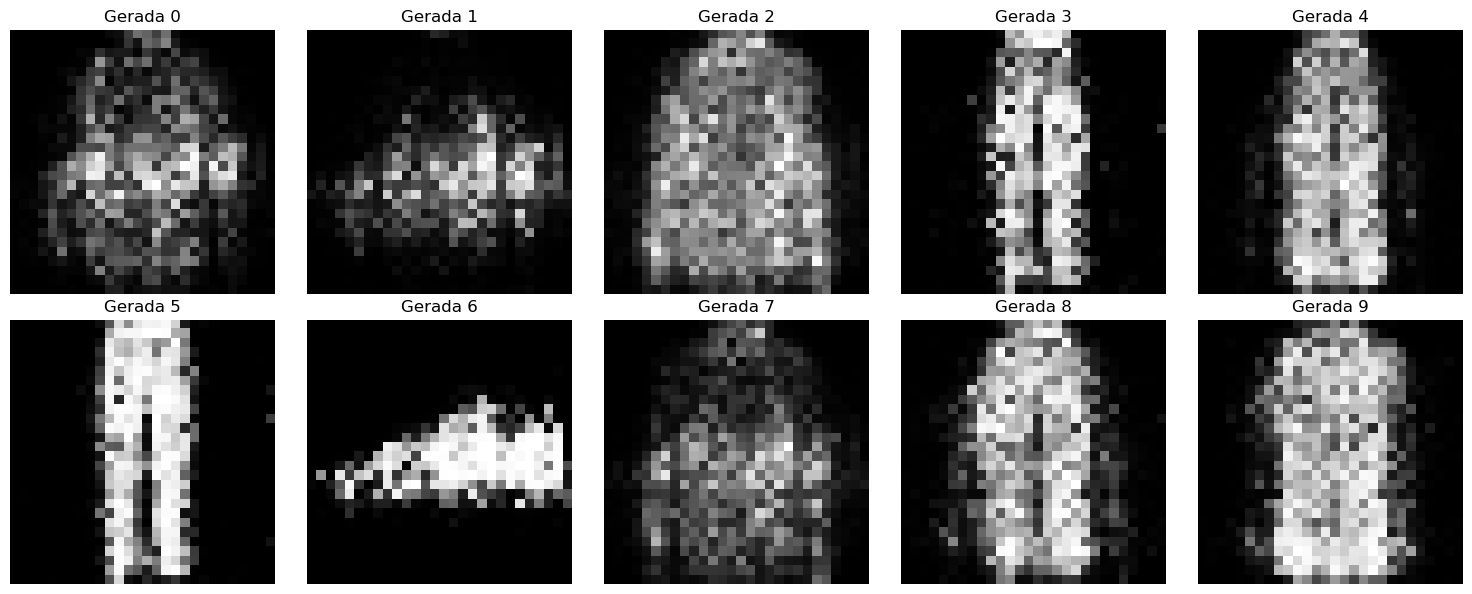

In [22]:
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(previsao[i].squeeze(), cmap='gray')
    plt.title(f"Gerada {i}")
    plt.axis('off')
plt.tight_layout()
plt.show()

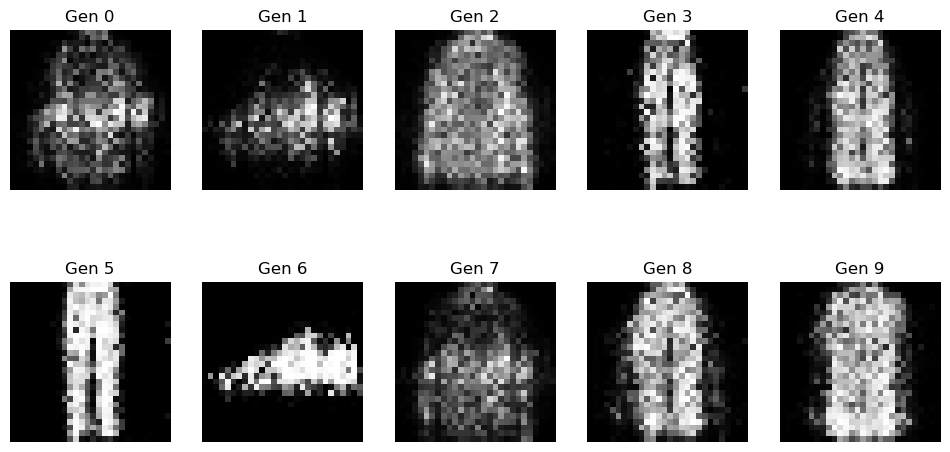

In [23]:
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(previsao[i].squeeze(), cmap='gray')
    plt.title(f"Gen {i}")
    plt.axis('off')
plt.show()

# teste imagens reais 

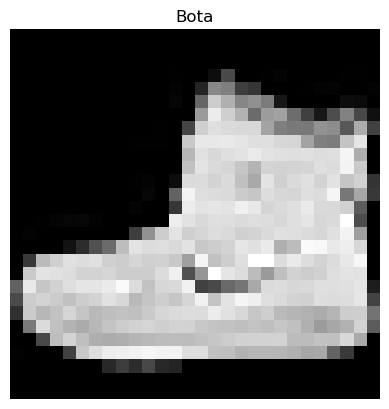

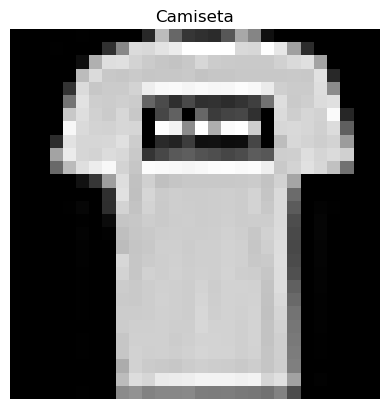

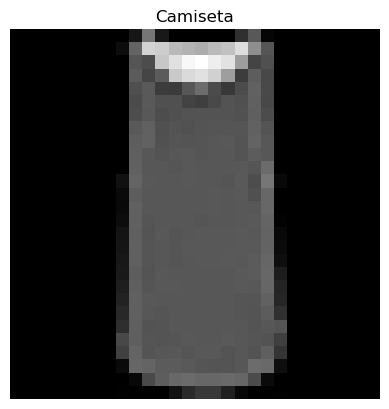

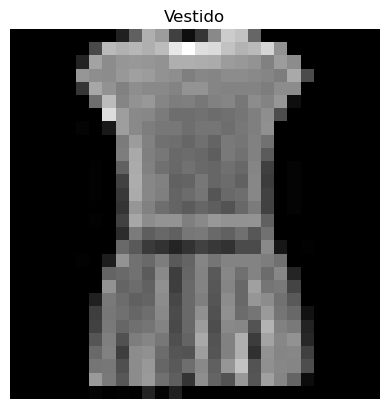

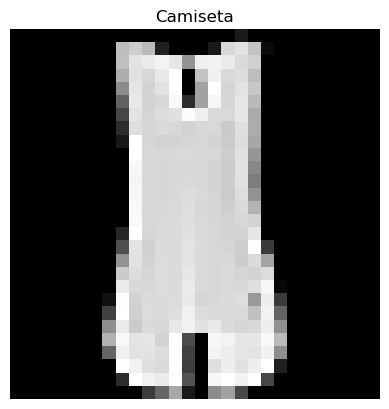

In [24]:
classes = ['Camiseta', 'Calça', 'Suéter', 'Vestido', 'Casaco', 
           'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

# Pegando um batch de imagens reais para testar
imagens_reais, rotulos = next(iter(train_loader))

for i in range(5): # Vamos ver as 5 primeiras
    plt.imshow(imagens_reais[i].squeeze(), cmap='gray')
    
    # Aqui usamos o classes! O 'rotulos[i]' é um número (ex: 9)
    # classes[9] retorna 'Bota'
    plt.title(classes[rotulos[i]]) 
    
    plt.axis('off')
    plt.show()